In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Modern, clean styling
sns.set_style('whitegrid')
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

# Brand colors (wellness theme)
PRIMARY = '#2E7D8F'  # Calm teal
ACCENT = '#E76F51'   # Warm coral
SUCCESS = '#52B788'  # Growth green
WARNING = '#FFB703'  # Attention amber
NEUTRAL = '#8D99AE'  # Soft gray

# Output directories (working directory is project root)
OUTPUT_BASE = Path('outputs/figures/business_2')

print("✓ Libraries loaded")
print(f"✓ Output directory: {OUTPUT_BASE}")

✓ Libraries loaded
✓ Output directory: outputs/figures/business_2


In [10]:
# Load data (working directory is already project root)
daily_revenue = pd.read_csv('data/processed/daily_revenue.csv')
daily_revenue['Date'] = pd.to_datetime(daily_revenue['Date'])
daily_revenue = daily_revenue.rename(columns={'Date': 'date', 'Revenue': 'revenue'})

service_list = pd.read_csv('data/processed/service_list_clean.csv')
association_rules = pd.read_csv('outputs/tables/association_rules_full.csv')
feature_importance = pd.read_csv('outputs/forecasts/feature_importance.csv')
customer_analysis = pd.read_csv('data/processed/customer_analysis.csv')

print(f"✓ Daily revenue: {len(daily_revenue)} days")
print(f"✓ Services: {len(service_list)} services")
print(f"✓ Association rules: {len(association_rules)} rules")
print(f"✓ Feature importance: {len(feature_importance)} features")
print(f"✓ Customer data: {len(customer_analysis)} customers")

✓ Daily revenue: 1276 days
✓ Services: 201 services
✓ Association rules: 10 rules
✓ Feature importance: 54 features
✓ Customer data: 1012 customers


---
## Recommendation 1: Service Bundles

**Speaker:** Rodrigo  
**Key Message:** Customers buy services separately - opportunity to create pathways

✓ Saved: recommendation_1/fig_1a_single_service.png


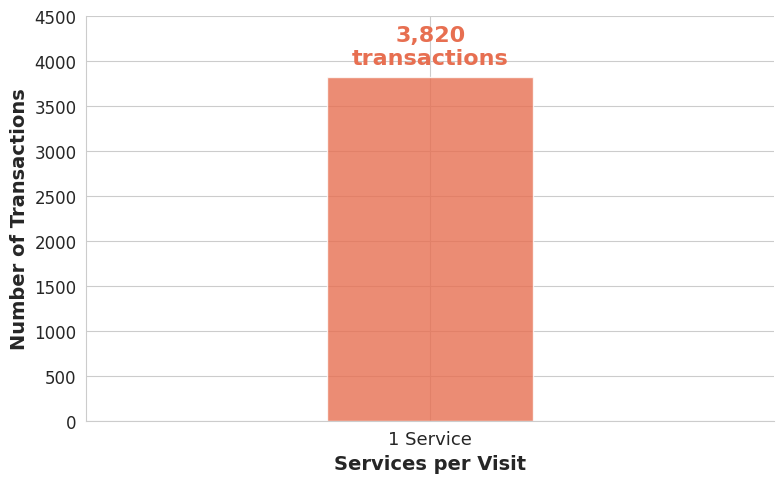

In [11]:
# Figure 1A: Single Service Problem
# Show that 100% of transactions = 1 service

fig, ax = plt.subplots(figsize=(8, 5))

# Simple bar chart
services_per_visit = [1]
transaction_count = [3820]

bars = ax.bar(services_per_visit, transaction_count, width=0.3, color=ACCENT, alpha=0.8)

# Add value on bar
ax.text(1, 3820 + 100, '3,820\ntransactions', ha='center', va='bottom', 
        fontsize=16, fontweight='bold', color=ACCENT)

ax.set_xlim(0.5, 1.5)
ax.set_ylim(0, 4500)
ax.set_xlabel('Services per Visit', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Transactions', fontsize=14, fontweight='bold')
ax.set_xticks([1])
ax.set_xticklabels(['1 Service'], fontsize=13)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_1' / 'fig_1a_single_service.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_1/fig_1a_single_service.png")
plt.show()

✓ Saved: recommendation_1/fig_1b_service_relationships.png


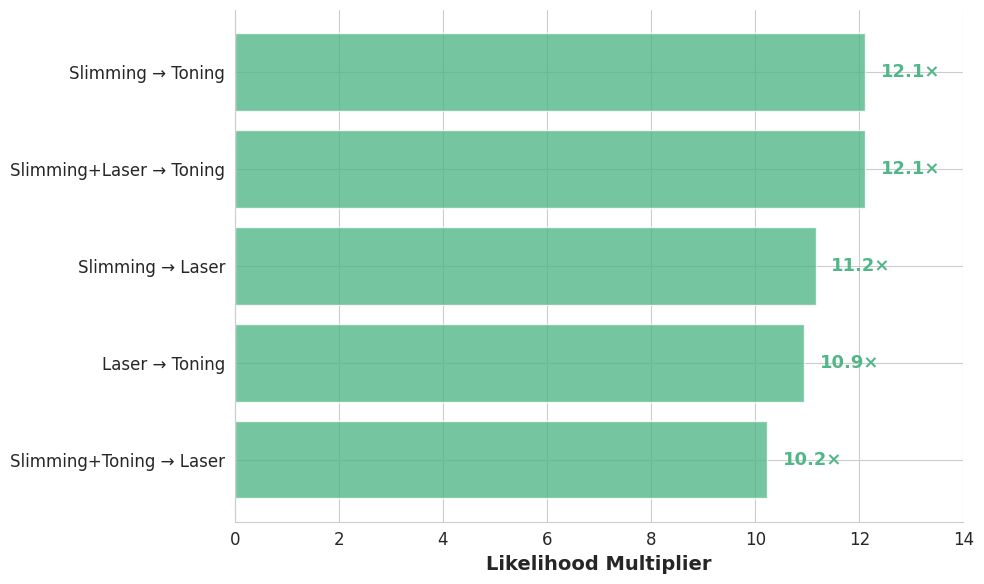

In [12]:
# Figure 1B: Top Service Relationships
# Show the strongest associations with lift values

top_rules = association_rules.nlargest(5, 'lift')[['antecedents', 'consequents', 'lift', 'confidence']]

# Simplify names
labels = [
    'Slimming → Toning',
    'Slimming+Laser → Toning',
    'Slimming → Laser',
    'Laser → Toning',
    'Slimming+Toning → Laser'
]
lift_values = top_rules['lift'].values

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(labels, lift_values, color=SUCCESS, alpha=0.8)

# Add lift values on bars
for i, (bar, val) in enumerate(zip(bars, lift_values)):
    ax.text(val + 0.3, i, f'{val:.1f}×', va='center', fontsize=13, fontweight='bold', color=SUCCESS)

ax.set_xlabel('Likelihood Multiplier', fontsize=14, fontweight='bold')
ax.set_xlim(0, 14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_1' / 'fig_1b_service_relationships.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_1/fig_1b_service_relationships.png")
plt.show()

✓ Saved: recommendation_1/fig_1c_revenue_comparison.png


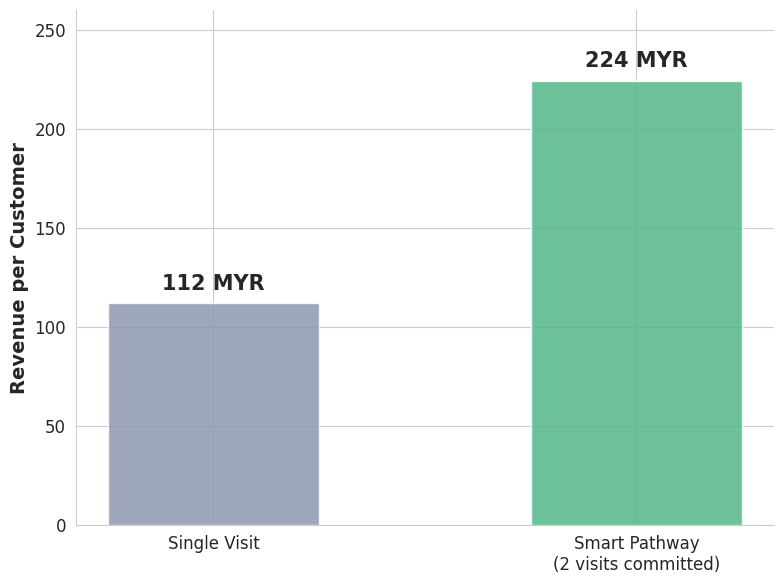

In [13]:
# Figure 1C: Revenue Comparison - Single vs Pathway
# Show revenue difference between single service and committed pathway

fig, ax = plt.subplots(figsize=(8, 6))

scenarios = ['Single Visit', 'Smart Pathway\n(2 visits committed)']
revenue = [112, 224]
colors = [NEUTRAL, SUCCESS]

bars = ax.bar(scenarios, revenue, color=colors, alpha=0.85, width=0.5)

# Add values on bars
for bar, val in zip(bars, revenue):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{val} MYR', ha='center', va='bottom', fontsize=15, fontweight='bold')

ax.set_ylabel('Revenue per Customer', fontsize=14, fontweight='bold')
ax.set_ylim(0, 260)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_1' / 'fig_1c_revenue_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_1/fig_1c_revenue_comparison.png")
plt.show()

---
## Recommendation 2: Promotional Calendar

**Speaker:** Molion  
**Key Message:** Tuesday gap and September trough = opportunities

✓ Saved: recommendation_2/fig_2a_weekly_demand.png


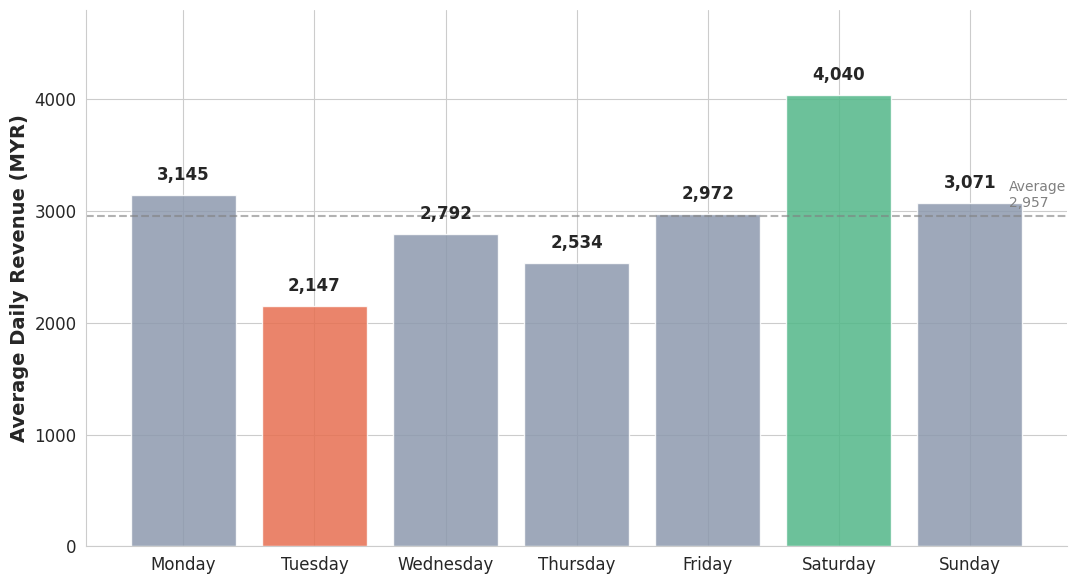

In [14]:
# Figure 2A: Weekly Demand Gap
# Show Tuesday vs Saturday revenue difference

daily_revenue['day_of_week'] = daily_revenue['date'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly_avg = daily_revenue.groupby('day_of_week')['revenue'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(11, 6))

# Color Tuesday and Saturday differently
colors_list = [NEUTRAL if day not in ['Tuesday', 'Saturday'] else 
               (ACCENT if day == 'Tuesday' else SUCCESS) for day in day_order]

bars = ax.bar(range(7), weekly_avg, color=colors_list, alpha=0.85)

# Add values on bars
for i, (day, val) in enumerate(zip(day_order, weekly_avg)):
    ax.text(i, val + 100, f'{val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Draw average line
avg_revenue = weekly_avg.mean()
ax.axhline(avg_revenue, color='gray', linestyle='--', linewidth=1.5, alpha=0.6)
ax.text(6.3, avg_revenue + 50, f'Average\n{avg_revenue:,.0f}', va='bottom', fontsize=10, color='gray')

ax.set_xticks(range(7))
ax.set_xticklabels(day_order, fontsize=12)
ax.set_ylabel('Average Daily Revenue (MYR)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 4800)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_2' / 'fig_2a_weekly_demand.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_2/fig_2a_weekly_demand.png")
plt.show()

✓ Saved: recommendation_2/fig_2b_seasonal_pattern.png


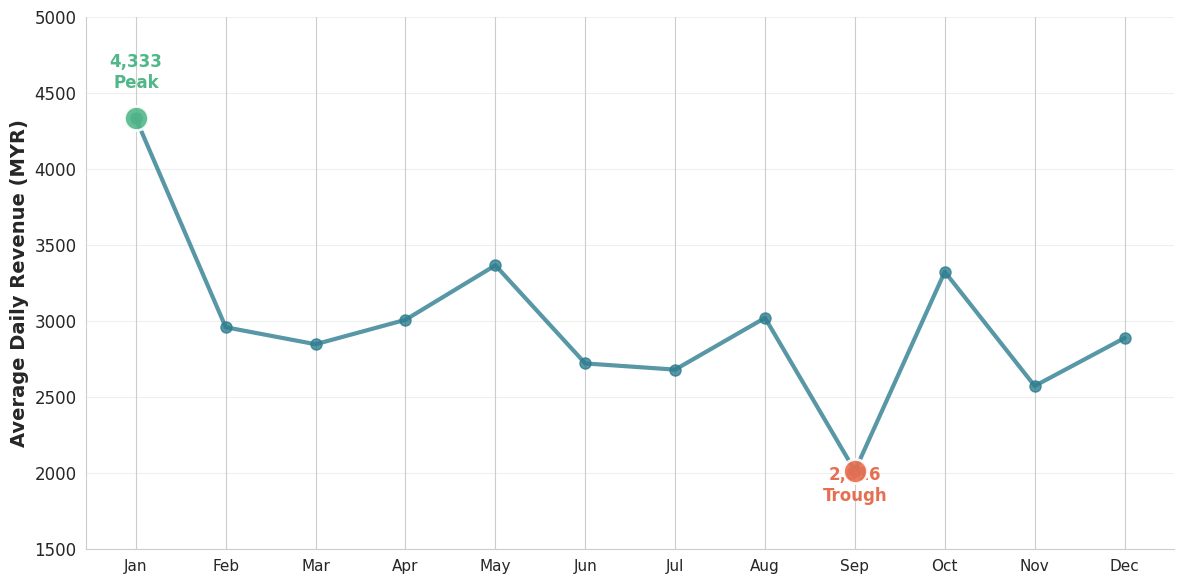

In [ ]:
# Figure 2B: Seasonal Pattern
# Show January peak vs September trough

daily_revenue['month'] = daily_revenue['date'].dt.month
monthly_avg = daily_revenue.groupby('month')['revenue'].mean()

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 6))

# Line plot
ax.plot(range(1, 13), monthly_avg, marker='o', linewidth=3, 
        markersize=8, color=PRIMARY, alpha=0.8)

# Highlight January and September
ax.scatter([1], [monthly_avg[1]], s=300, color=SUCCESS, alpha=0.9, zorder=5, edgecolor='white', linewidth=2)
ax.scatter([9], [monthly_avg[9]], s=300, color=ACCENT, alpha=0.9, zorder=5, edgecolor='white', linewidth=2)

# Add labels
ax.text(1, monthly_avg[1] + 200, f'{monthly_avg[1]:,.0f}\nPeak', 
        ha='center', fontsize=12, fontweight='bold', color=SUCCESS)
ax.text(9, monthly_avg[9] - 200, f'\n{monthly_avg[9]:,.0f}\nTrough', 
        ha='center', fontsize=12, fontweight='bold', color=ACCENT)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_names, fontsize=11)
ax.set_ylabel('Average Daily Revenue (MYR)', fontsize=14, fontweight='bold')
ax.set_ylim(1500, 5000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_2' / 'fig_2b_seasonal_pattern.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_2/fig_2b_seasonal_pattern.png")
plt.show()

✓ Saved: recommendation_2/fig_2c_financial_impact.png


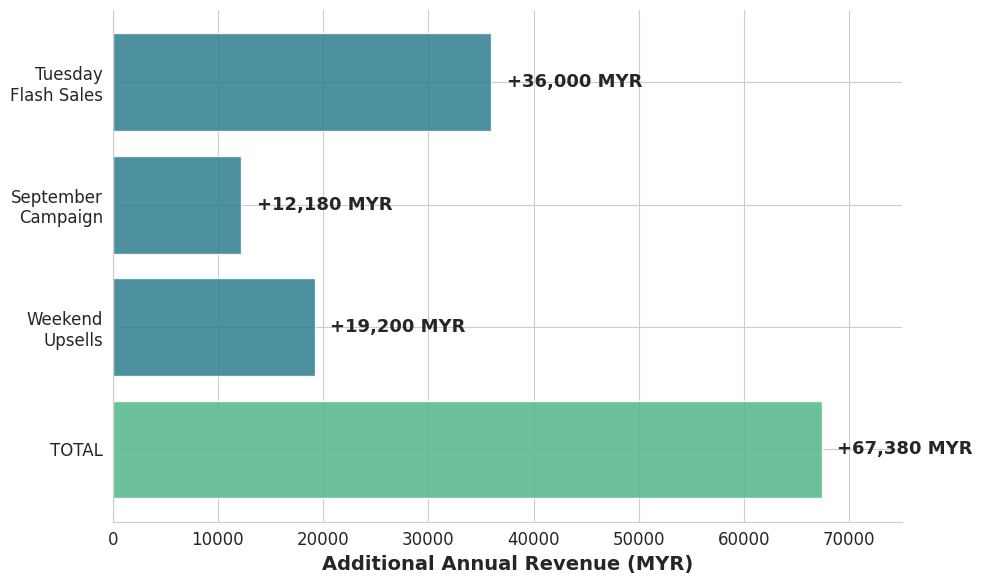

In [16]:
# Figure 2C: Financial Impact Summary
# Show three initiatives and total

fig, ax = plt.subplots(figsize=(10, 6))

initiatives = ['Tuesday\nFlash Sales', 'September\nCampaign', 'Weekend\nUpsells', 'TOTAL']
amounts = [36000, 12180, 19200, 67380]
colors_list = [PRIMARY, PRIMARY, PRIMARY, SUCCESS]

bars = ax.barh(initiatives, amounts, color=colors_list, alpha=0.85)

# Add values
for i, (bar, val) in enumerate(zip(bars, amounts)):
    ax.text(val + 1500, i, f'+{val:,} MYR', va='center', fontsize=13, fontweight='bold')

ax.set_xlabel('Additional Annual Revenue (MYR)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 75000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_2' / 'fig_2c_financial_impact.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_2/fig_2c_financial_impact.png")
plt.show()

---
## Recommendation 3: Service Mix Optimization

**Speaker:** Andrew  
**Key Message:** Portfolio too bottom-heavy, need mid-tier focus

✓ Saved: recommendation_3/fig_3a_portfolio_distribution.png


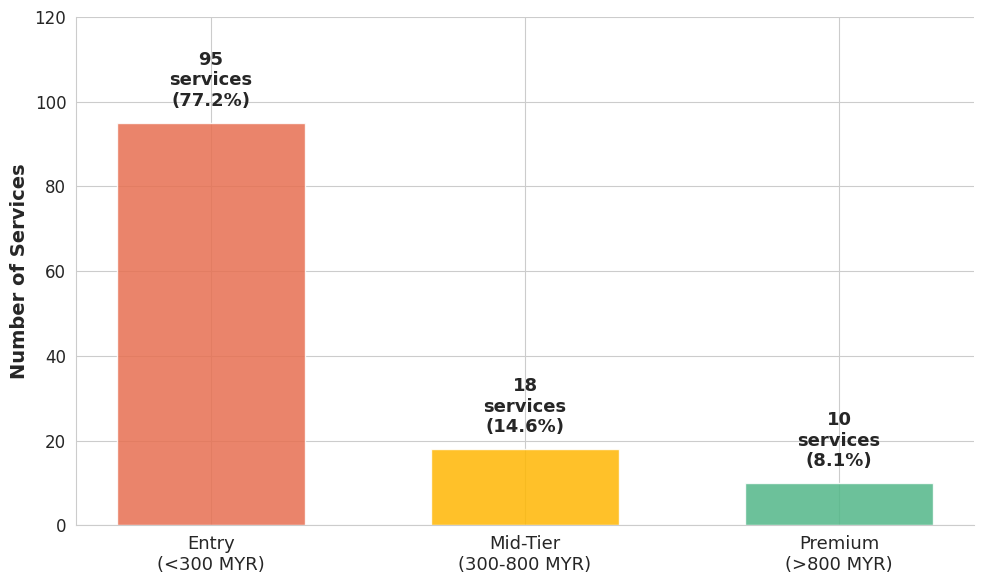

In [18]:
# Figure 3A: Current Portfolio Distribution
# Show 78% entry-level imbalance

# Load RPT data
rpt_data = pd.read_csv('data/processed/rpt_by_service.csv')

# Create tier categories
rpt_data['tier'] = pd.cut(rpt_data['RPT'], 
                           bins=[0, 300, 800, float('inf')],
                           labels=['Entry\n(<300 MYR)', 'Mid-Tier\n(300-800 MYR)', 'Premium\n(>800 MYR)'])

tier_counts = rpt_data['tier'].value_counts().sort_index()
tier_pct = (tier_counts / tier_counts.sum() * 100)

fig, ax = plt.subplots(figsize=(10, 6))

colors_list = [ACCENT, WARNING, SUCCESS]
bars = ax.bar(range(3), tier_counts, color=colors_list, alpha=0.85, width=0.6)

# Add counts and percentages
for i, (bar, count, pct) in enumerate(zip(bars, tier_counts, tier_pct)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 3,
            f'{count}\nservices\n({pct:.1f}%)', ha='center', va='bottom', 
            fontsize=13, fontweight='bold')

ax.set_xticks(range(3))
ax.set_xticklabels(tier_counts.index, fontsize=13)
ax.set_ylabel('Number of Services', fontsize=14, fontweight='bold')
ax.set_ylim(0, 120)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_3' / 'fig_3a_portfolio_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_3/fig_3a_portfolio_distribution.png")
plt.show()

TypeError: alpha must be numeric or None, not <class 'list'>

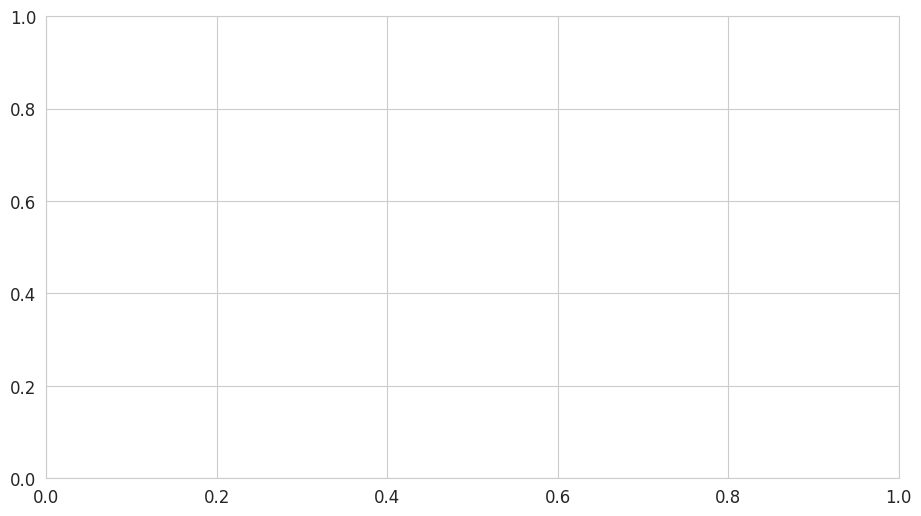

In [19]:
# Figure 3B: Three-Tier Framework
# Simple visual showing Good/Better/Best with price ranges

fig, ax = plt.subplots(figsize=(11, 6))

tiers = ['GOOD', 'BETTER', 'BEST']
prices = ['100-150', '300-800', '800+']
colors_list = [NEUTRAL, WARNING, SUCCESS]
alphas = [0.6, 0.85, 0.85]
heights = [1, 1.3, 1.1]  # BETTER is emphasized

bars = ax.bar(range(3), heights, color=colors_list, alpha=alphas, width=0.6)

# Add tier names and prices
for i, (bar, tier, price, height) in enumerate(zip(bars, tiers, prices, heights)):
    ax.text(i, height/2, f'{tier}\n{price} MYR', 
            ha='center', va='center', fontsize=14, fontweight='bold', color='white')

ax.set_xticks(range(3))
ax.set_xticklabels(['Entry', 'Recommended', 'Premium'], fontsize=13)
ax.set_ylim(0, 1.6)
ax.set_yticks([])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_3' / 'fig_3b_tier_framework.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_3/fig_3b_tier_framework.png")
plt.show()

In [ ]:
# Figure 3C: Revenue Per Appointment Shift
# Before vs After comparison

fig, ax = plt.subplots(figsize=(8, 6))

scenarios = ['Current', 'Target']
rpt_values = [118, 175]
colors_list = [NEUTRAL, SUCCESS]

bars = ax.bar(scenarios, rpt_values, color=colors_list, alpha=0.85, width=0.5)

# Add values
for bar, val in zip(bars, rpt_values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{val} MYR', ha='center', va='bottom', fontsize=15, fontweight='bold')

# Add arrow showing increase
ax.annotate('', xy=(1, 175), xytext=(0, 118),
            arrowprops=dict(arrowstyle='->', lw=2.5, color=SUCCESS, alpha=0.7))
ax.text(0.5, 145, '+48%', ha='center', fontsize=14, fontweight='bold', color=SUCCESS)

ax.set_ylabel('Revenue per Appointment (MYR)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 200)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_3' / 'fig_3c_rpt_shift.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_3/fig_3c_rpt_shift.png")
plt.show()

---
## Recommendation 4: Demand-Based Staffing

**Speaker:** Kenny  
**Key Message:** Day of week is #1 driver, align staffing to demand

In [ ]:
# Figure 4A: Top Revenue Drivers
# Show day_of_week as #1 feature

top_features = feature_importance.head(8)

# Simplify feature names
simple_names = [
    'Day of Week',
    'Transaction Count',
    'Recent Revenue (7d)',
    'Avg Revenue per Employee',
    'Unique Customers',
    'Post Holiday',
    'Month End Effect',
    'Revenue Peak (7d)'
]

fig, ax = plt.subplots(figsize=(10, 6))

colors_list = [SUCCESS if i == 0 else PRIMARY for i in range(len(top_features))]
bars = ax.barh(simple_names[::-1], top_features['importance'].values[::-1], 
               color=colors_list[::-1], alpha=0.85)

# Add values
for i, (bar, val) in enumerate(zip(bars, top_features['importance'].values[::-1])):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Importance Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, 0.32)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_4' / 'fig_4a_top_drivers.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_4/fig_4a_top_drivers.png")
plt.show()

In [ ]:
# Figure 4B: Staffing Alignment
# Show revenue vs recommended staff by day

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_revenue['day_of_week'] = daily_revenue['date'].dt.day_name()
weekly_avg = daily_revenue.groupby('day_of_week')['revenue'].mean().reindex(day_order)

# Calculate recommended staff (roughly 600 MYR per staff member)
recommended_staff = (weekly_avg / 600).round()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Revenue bars
x = range(7)
ax1.bar(x, weekly_avg, color=PRIMARY, alpha=0.7, label='Revenue')
ax1.set_xlabel('Day of Week', fontsize=14, fontweight='bold')
ax1.set_ylabel('Revenue (MYR)', fontsize=14, fontweight='bold', color=PRIMARY)
ax1.tick_params(axis='y', labelcolor=PRIMARY)
ax1.set_xticks(x)
ax1.set_xticklabels(day_order, fontsize=11)

# Staff line
ax2 = ax1.twinx()
ax2.plot(x, recommended_staff, color=ACCENT, marker='o', linewidth=3, 
         markersize=10, label='Staff Needed', alpha=0.9)
ax2.set_ylabel('Recommended Staff', fontsize=14, fontweight='bold', color=ACCENT)
ax2.tick_params(axis='y', labelcolor=ACCENT)
ax2.set_ylim(0, 10)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_4' / 'fig_4b_staffing_alignment.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_4/fig_4b_staffing_alignment.png")
plt.show()

In [ ]:
# Figure 4C: Financial Impact Breakdown
# Show labor savings + captured revenue

fig, ax = plt.subplots(figsize=(10, 6))

components = ['Labor\nSavings', 'Captured\nWeekend Revenue', 'TOTAL']
amounts = [26780, 61360, 88140]
colors_list = [PRIMARY, PRIMARY, SUCCESS]

bars = ax.barh(components, amounts, color=colors_list, alpha=0.85)

# Add values
for i, (bar, val) in enumerate(zip(bars, amounts)):
    ax.text(val + 1500, i, f'+{val:,} MYR', va='center', fontsize=13, fontweight='bold')

ax.set_xlabel('Annual Impact (MYR)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 100000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_4' / 'fig_4c_financial_breakdown.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_4/fig_4c_financial_breakdown.png")
plt.show()

---
## Recommendation 5: Customer Retention

**Speaker:** Kenny  
**Key Message:** Increase visits from 3.7 to 5.0 for massive CLV gain

In [ ]:
# Figure 5A: Customer Visit Distribution
# Show current visit frequency with average

# Create visit distribution
visit_counts = customer_analysis['visit_count'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(visit_counts.index, visit_counts.values, color=PRIMARY, alpha=0.7)

# Add average line
avg_visits = customer_analysis['visit_count'].mean()
ax.axvline(avg_visits, color=ACCENT, linestyle='--', linewidth=2.5, alpha=0.8)
ax.text(avg_visits + 0.3, ax.get_ylim()[1] * 0.9, f'Average\n{avg_visits:.1f} visits', 
        fontsize=12, fontweight='bold', color=ACCENT)

ax.set_xlabel('Number of Visits', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Customers', fontsize=14, fontweight='bold')
ax.set_xlim(0, 20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_5' / 'fig_5a_visit_distribution.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_5/fig_5a_visit_distribution.png")
plt.show()

In [ ]:
# Figure 5B: Retention System Components
# Show three retention mechanisms as simple bars

fig, ax = plt.subplots(figsize=(10, 6))

mechanisms = ['Tiered\nLoyalty', '30-Day\nTrigger', 'Personalized\nRecommendations']
impact = [55365, 86376, 67200]

bars = ax.bar(mechanisms, impact, color=[SUCCESS, WARNING, PRIMARY], alpha=0.85, width=0.6)

# Add values
for bar, val in zip(bars, impact):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2000,
            f'+{val:,}\nMYR', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Annual Revenue Impact (MYR)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 100000)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_5' / 'fig_5b_retention_mechanisms.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_5/fig_5b_retention_mechanisms.png")
plt.show()

In [ ]:
# Figure 5C: Lifetime Value Opportunity
# Before vs After CLV comparison

fig, ax = plt.subplots(figsize=(9, 6))

scenarios = ['Current\n(3.7 visits)', 'Target\n(5.0 visits)']
clv = [441, 592]
colors_list = [NEUTRAL, SUCCESS]

bars = ax.bar(scenarios, clv, color=colors_list, alpha=0.85, width=0.5)

# Add values
for bar, val in zip(bars, clv):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 15,
            f'{val} MYR', ha='center', va='bottom', fontsize=15, fontweight='bold')

# Add arrow showing increase
ax.annotate('', xy=(1, 592), xytext=(0, 441),
            arrowprops=dict(arrowstyle='->', lw=2.5, color=SUCCESS, alpha=0.7))
ax.text(0.5, 515, '+34%', ha='center', fontsize=14, fontweight='bold', color=SUCCESS)

ax.set_ylabel('Customer Lifetime Value (MYR)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 700)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUTPUT_BASE / 'recommendation_5' / 'fig_5c_clv_opportunity.png', dpi=300, bbox_inches='tight')
print("✓ Saved: recommendation_5/fig_5c_clv_opportunity.png")
plt.show()

---
## Summary

All visualizations created and saved to `outputs/figures/business_2/`

In [ ]:
# List all created figures
import os

print("\n" + "="*60)
print("CREATED VISUALIZATIONS")
print("="*60 + "\n")

for rec in range(1, 6):
    rec_path = OUTPUT_BASE / f'recommendation_{rec}'
    files = sorted(rec_path.glob('*.png'))
    print(f"\nRecommendation {rec}: ({len(files)} figures)")
    for f in files:
        print(f"  ✓ {f.name}")

print("\n" + "="*60)
print("Ready for PowerPoint integration!")
print("="*60)